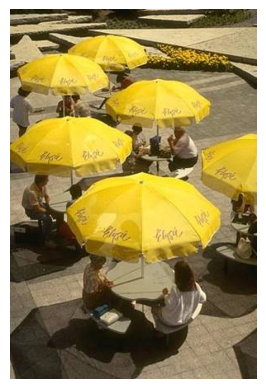

0번째 이미지 예측 : 
클래스 : umbrella
확률 : 98.76% 



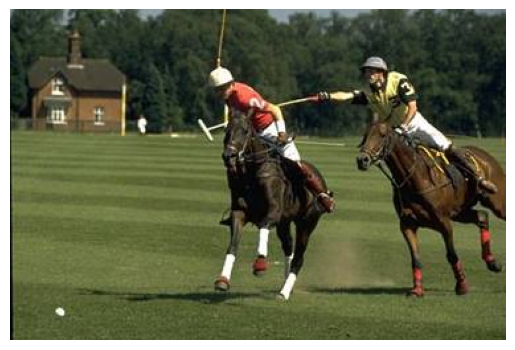

1번째 이미지 예측 : 
클래스 : croquet ball
확률 : 3.90% 



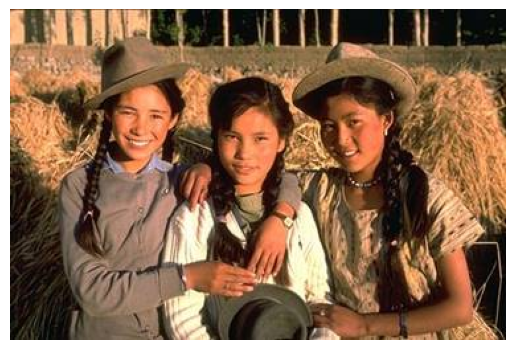

2번째 이미지 예측 : 
클래스 : hay
확률 : 18.51% 



In [3]:
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import torch
import matplotlib.pylab as plt

imgs = [Image.open('./images/BSDS_242078.jpg'),
        Image.open('./images/BSDS_361010.jpg'),
        Image.open('./images/BSDS_376001.jpg')]

processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")

inputs = processor(images=imgs, return_tensors = "pt")

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    probs = logits.softmax(dim = -1)

for i in range(len(imgs)):
    plt.imshow(imgs[i])
    plt.axis("off")
    plt.show()

    pred_idx = int(torch.argmax(probs[i]))
    pred_label = model.config.id2label[pred_idx]
    pred_prob = float(probs[i][pred_idx] * 100)

    print(f"{i}번째 이미지 예측 : ")
    print(f"클래스 : {pred_label}")
    print(f"확률 : {pred_prob:.2f}% \n")


In [1]:
from transformers import DetrImageProcessor, DetrForObjectDetection
from PIL import Image
import torch
import numpy as np
import cv2 as cv

img = Image.open("./images/BSDS_361010.jpg")

processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")

inputs = processor(images=img, return_tensors="pt")
outputs = model(**inputs)

target_sizes = torch.tensor([img.size[::-1]])
results = processor.post_process_object_detection(outputs, threshold=0.7, target_sizes=target_sizes)[0]

im = cv.cvtColor(np.array(img), cv.COLOR_RGB2BGR)
colors = np.random.uniform(0, 255, size=(100, 3))

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    x_min, y_min, x_max, y_max = map(int, box.tolist())
    color = colors[label.item() % 100]
    name = model.config.id2label[label.item()]
    cv.rectangle(im, (x_min, y_min), (x_max, y_max), color, 2)
    cv.putText(im, f"{name} {score.item():.2f}", (x_min, y_min - 5), cv.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

cv.imshow("DETR", im)
cv.waitKey(0)
cv.destroyAllWindows()

c:\Users\asus\anaconda3\envs\dmu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Error while downloading from https://huggingface.co/timm/resnet50.a1_in1k/resolve/main/model.safetensors: HTTPSConnectionPool(host='cas-bridge.xethub.hf.co', port=443): Read timed out.
Trying to resume download...
c:\Users\asus\anaconda3\envs\dmu\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\asus\.cache\huggingface\hub\models--timm--resnet50.

In [3]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image

img = Image.open("./images/BSDS_361010.jpg")

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")

captions = ['Two hores are running on grass',
            'Students are eating',
            'Croquet playing on hores',
            'Golf playing on hores']

inputs = processor(text=captions, images=img, return_tensors="pt", padding=True)
res = model(**inputs)

import matplotlib.pyplot as plt
plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.show()

logits = res.logits_per_image
probs = logits.softmax(dim=1)

for i in range(len(captions)):
    print(captions[i], ': ', '{:.2f}'.format(float(probs[0, i] * 100.0)))

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
c:\Users\asus\anaconda3\envs\dmu\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\asus\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer 

ChunkedEncodingError: ('Connection broken: IncompleteRead(255205023 bytes read, 66926528 more expected)', IncompleteRead(255205023 bytes read, 66926528 more expected))